# HP 8168D / HP 8168E Tunable Laser Source — GPIB Control

**Instrument:** HP / Agilent 8168D or 8168E Tunable Laser Source  
**Verified against:** `HEWLETT-PACKARD,HP8168D,...,5.00` (firmware 5.00)  
**Interface:** GPIB-USB Adapter (NI GPIB-USB-HS or equivalent)  
**Units:** Wavelength sent in **metres**, returned in metres (scientific notation) · Power in **watts**, displayed in µW and dBm

---

> ## ⚠️ LASER SAFETY
> The HP 8168D/E are **Class IIIb / Class 3A** lasers (up to ~1.6 mW).
> - Never view the fiber output directly or with optical instruments.
> - Confirm the optical path is connected before calling `tls_output_on()`.
> - `tls_output_off()` runs automatically at the end of every sweep.
> - Always run the **Cleanup** cell at the end of a session.

---

> ## ✅ CONFIRMED COMMAND SET (this unit)
> Empirically verified via the Command Discovery cell:
> | Function | Command | Notes |
> |---|---|---|
> | Wavelength | `:WAVELENGTH` / `?` | value in **metres** |
> | Power | `:POWER` / `?` | value in **watts** |
> | Output enable | `:OUTPUT` / `?` | returns `+0` / `+1` |
> | Power unit | `:POWER:UNIT?` | this unit reports `+2` (watts) |
> | AM source | `:SOURCE:AM:SOURCE` | numeric codes **0, 1, 2** |
> | AM state | `:SOURCE:AM:STATE` | ON / OFF |
> | AM int. freq | `:SOURCE:AM:INTERNAL:FREQUENCY` | Hz (default 80 kHz) |
> | Options | `*OPT?` | reports installed hardware |
> | Identity | `*IDN?` | works on this firmware |
> | Status | `*STB?` `*ESR?` `*OPC?` `:STATUS:OPERATION:CONDITION?` | |
> | Errors | `:SYSTEM:ERROR?` | one error per query |
>
> **NOT remotely addressable on this unit:**
> - **Coherence control** — hardware is installed (shows in `*OPT?`) but there is
>   no GPIB command on 8168D fw 5.00. Set it on the **front panel**.
> - **Hardware wavelength sweep** — no `:SWEEP` subsystem; the software
>   step-and-dwell loop below is the only option.
> - **Built-in attenuator** — option not installed on this unit.
>
> **Wavelength step resolution (hardware-limited):**
> - **8168D: 100 pm (0.100 nm)**
> - **8168E:  10 pm (0.010 nm)**
> Requested wavelengths are snapped to this grid automatically.

---
**How to use:**
1. Edit the **Configuration Block** (Cell 2) — set `TLS_MODEL` correctly.
2. Run imports/connection (Cell 3) and function definitions (Cell 4).
3. Use the example cells, or the Command Discovery cell to re-verify.

## ⚙️ CONFIGURATION BLOCK — Edit All Parameters Here

In [81]:
# ============================================================
#  GPIB CONNECTION
# ============================================================
GPIB_ADDR_HP8168   = 2      # GPIB address (front-panel display, default 24)
GPIB_BOARD_INDEX   = 2       # USB-GPIB adapter index (0 = first/only adapter)

# ============================================================
#  INSTRUMENT MODEL  — controls wavelength range AND step resolution
#    8168D: 1490–1565 nm, 100 pm step
#    8168E: 1475–1575 nm,  10 pm step
# ============================================================
TLS_MODEL          = '8168D' # set to your actual model — '8168D' or '8168E'

# ============================================================
#  CONFIRMED COMMAND MNEMONICS (verified on HP8168D fw 5.00)
# ============================================================
CMD_WAVELENGTH     = ':WAVELENGTH'          # set/query, metres
CMD_POWER          = ':POWER'               # set/query, watts
CMD_OUTPUT         = ':OUTPUT'              # laser output enable
CMD_POWER_UNIT     = ':POWER:UNIT'          # 0=dBm, 1=Watt (this unit reports 2)
CMD_AM_SOURCE      = ':SOURCE:AM:SOURCE'    # numeric code 0/1/2
CMD_AM_STATE       = ':SOURCE:AM:STATE'     # ON/OFF
CMD_AM_INT_FREQ    = ':SOURCE:AM:INTERNAL:FREQUENCY'  # Hz
CMD_COHERENCE      = None                   # not GPIB-addressable — front panel only

# ============================================================
#  LASER PARAMETERS  (power in watts; use helpers to convert)
#    100e-6  =  100 µW ≈ -10.0 dBm      500e-6 = 500 µW ≈ -3.0 dBm
#    200e-6  =  200 µW ≈  -7.0 dBm     1000e-6 = 1 mW   =  0.0 dBm
# ============================================================
TLS_WAVELENGTH_NM  = 1550.1  # Output wavelength nm
TLS_POWER_W        = 200e-6  # Output power watts (8168D/E max ~1.6 mW)
TLS_OUTPUT_ENABLE  = True   # ⚠️ True = laser ON at configure

# ============================================================
#  STEPPED WAVELENGTH SWEEP (software loop — no hardware sweep on this unit)
# ============================================================
TLS_SWEEP_START_NM = 1520.0
TLS_SWEEP_STOP_NM  = 1570.0
TLS_SWEEP_STEP_NM  = 1.0     # snapped to the model's step grid automatically
TLS_SWEEP_DWELL_S  = 0.5

# ============================================================
#  FILE OUTPUT / TIMING
# ============================================================
OUTPUT_DIR         = './data_tls'
QUERY_DELAY_S      = 0.15
QUERY_TIMEOUT_MS   = 5000

# ── Model-derived limits & step resolution ───────────────────────────────────
_MODEL_SPECS = {
    #          (wl_min, wl_max, step_nm)
    '8168D': (1480.0, 1570.0, 0.100),   # 100 pm
    '8168E': (1475.0, 1575.0, 0.010),   #  10 pm
}
TLS_WL_MIN, TLS_WL_MAX, TLS_WL_STEP_NM = _MODEL_SPECS.get(
    TLS_MODEL, (1475.0, 1575.0, 0.010))

print(f"HP {TLS_MODEL} configuration loaded.")
print(f"Wavelength range : {TLS_WL_MIN} – {TLS_WL_MAX} nm")
print(f"Step resolution  : {TLS_WL_STEP_NM*1e3:.0f} pm ({TLS_WL_STEP_NM:.3f} nm)")
print(f"Set power        : {TLS_POWER_W*1e6:.1f} µW")

HP 8168D configuration loaded.
Wavelength range : 1480.0 – 1570.0 nm
Step resolution  : 100 pm (0.100 nm)
Set power        : 200.0 µW


## 📦 Imports & Instrument Connection

In [60]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import datetime

os.makedirs(OUTPUT_DIR, exist_ok=True)

rm = pyvisa.ResourceManager()
resources = rm.list_resources()
print(f"Found {len(resources)} VISA resource(s): {resources}")

tls = rm.open_resource(f'GPIB{GPIB_BOARD_INDEX}::{GPIB_ADDR_HP8168}::INSTR')
tls.timeout          = 15000
tls.read_termination  = '\n'
tls.write_termination = '\n'
print(f"Opened: GPIB{GPIB_BOARD_INDEX}::{GPIB_ADDR_HP8168}::INSTR")

tls.write('*CLS')   # Clear status/error registers left over from any prior session

for probe_cmd in ['*IDN?', '*OPT?']:
    try:
        tls.timeout = 3000
        print(f"  {probe_cmd:<8} → {tls.query(probe_cmd).strip()}")
    except pyvisa.errors.VisaIOError:
        print(f"  {probe_cmd:<8} → (no response)")
tls.timeout = 15000
print("\nConnection ready.")

Found 12 VISA resource(s): ('ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL8::INSTR', 'ASRL10::INSTR', 'ASRL13::INSTR', 'ASRL14::INSTR', 'GPIB0::18::INSTR', 'GPIB0::1::INSTR', 'GPIB0::2::INSTR', 'GPIB1::1::INSTR', 'GPIB2::2::INSTR')
Opened: GPIB2::2::INSTR
  *IDN?    → HEWLETT-PACKARD,HP8168D,3610G00108,5.00
  *OPT?    → PASSIVE COMPONENT TEST,0,0,COHERENCE CONTROL

Connection ready.


## 🔧 Function Definitions

In [79]:
# ══════════════════════════════════════════════════════════════════════════════
#  SAFE I/O WRAPPERS
#  The 8168 silently discards unrecognized queries (surfaces as a read timeout)
#  and silently rejects bad writes (logged in the error queue). These wrappers
#  surface both instead of failing blindly.
# ══════════════════════════════════════════════════════════════════════════════

def tls_check_error():
    """Drain and print the instrument error queue (:SYSTEM:ERROR?)."""
    errors = []
    try:
        for _ in range(20):
            tls.timeout = 2000
            resp = tls.query(':SYSTEM:ERROR?').strip()
            errors.append(resp)
            if resp.split(',')[0].strip() in ('0', '+0'):
                break
    except pyvisa.errors.VisaIOError:
        print("  (:SYSTEM:ERROR? did not respond)")
        tls.timeout = 15000
        return None
    tls.timeout = 15000
    for e in errors:
        print(f"  ERR: {e}")
    return errors


def safe_query(cmd, timeout_ms=QUERY_TIMEOUT_MS):
    """Query and return stripped response, or None on timeout (warns + checks errors)."""
    old = tls.timeout
    tls.timeout = timeout_ms
    try:
        return tls.query(cmd).strip()
    except pyvisa.errors.VisaIOError:
        print(f"⚠️  Query timed out: '{cmd}'")
        tls_check_error()
        return None
    finally:
        tls.timeout = old


def safe_query_float(cmd, timeout_ms=QUERY_TIMEOUT_MS):
    """safe_query parsed to float, or None."""
    resp = safe_query(cmd, timeout_ms)
    if resp is None:
        return None
    try:
        return float(resp)
    except ValueError:
        print(f"⚠️  Could not parse float from: '{resp}'")
        return None


def safe_write(cmd, check=True):
    """
    Write a command and (optionally) verify it was accepted via the error queue.
    The 8168 fails writes silently, so check=True catches rejected commands.

    Returns
    -------
    ok : bool — True if no error was queued (or check skipped)
    """
    tls.write(cmd)
    if not check:
        return True
    time.sleep(0.05)
    try:
        tls.timeout = 2000
        err = tls.query(':SYSTEM:ERROR?').strip()
    except pyvisa.errors.VisaIOError:
        tls.timeout = 15000
        return True   # Can't check; assume OK
    tls.timeout = 15000
    if err.split(',')[0].strip() not in ('0', '+0'):
        print(f"⚠️  Command rejected: '{cmd}' → {err}")
        return False
    return True


# ══════════════════════════════════════════════════════════════════════════════
#  UNIT CONVERSION HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def dbm_to_w(dbm):  return 10 ** (dbm / 10.0) * 1e-3
def w_to_dbm(w):    return 10.0 * np.log10(w / 1e-3)
def uw_to_w(uw):    return uw * 1e-6
def w_to_uw(w):     return w * 1e6


# ══════════════════════════════════════════════════════════════════════════════
#  INSTRUMENT CONTROL
# ══════════════════════════════════════════════════════════════════════════════

def tls_reset():
    """Reset to defaults. Output OFF afterward. Waits 2 s."""
    tls.write('*RST'); tls.write('*CLS'); time.sleep(2)
    print("HP 8168 reset complete. Laser output is OFF.")

def tls_clear():
    """GPIB Device Clear + *CLS to recover from a hang or error state."""
    tls.clear(); tls.write('*CLS'); print("HP 8168 cleared.")

def tls_go_to_local():
    """Return front-panel control to the operator."""
    tls.write('*GTL'); print("HP 8168 returned to local control.")

def tls_get_idn():
    """Query *IDN?."""
    idn = safe_query('*IDN?'); print(f"IDN: {idn}"); return idn

def tls_get_options():
    """Report installed hardware options via *OPT?."""
    opts = safe_query('*OPT?'); print(f"Options: {opts}"); return opts

def tls_self_test():
    """Run *TST?. Returns 0=pass, non-zero=fail code, or None on timeout."""
    resp = safe_query('*TST?', timeout_ms=20000)
    if resp is None:
        return None
    result = int(float(resp))
    print(f"Self-test: {'PASS' if result == 0 else f'FAIL (code {result})'}")
    return result

def tls_status():
    """
    Read the status registers.
    Returns a dict: stb, esr, operation_condition.
    """
    stb = safe_query('*STB?')
    esr = safe_query('*ESR?')
    opc = safe_query(':STATUS:OPERATION:CONDITION?')
    print(f"  *STB? = {stb}   *ESR? = {esr}   OPER:COND = {opc}")
    return {'stb': stb, 'esr': esr, 'operation_condition': opc}


# ══════════════════════════════════════════════════════════════════════════════
#  WAVELENGTH CONTROL  (metres on the bus; nm in the API; snapped to model grid)
# ══════════════════════════════════════════════════════════════════════════════

def _check_wavelength(wl_nm):
    if not (TLS_WL_MIN <= wl_nm <= TLS_WL_MAX):
        raise ValueError(
            f"Wavelength {wl_nm:.3f} nm is outside HP {TLS_MODEL} range "
            f"({TLS_WL_MIN}–{TLS_WL_MAX} nm).")

def _snap_wavelength(wl_nm):
    """Snap a wavelength to the model's step grid (100 pm for D, 10 pm for E)."""
    snapped = round(wl_nm / TLS_WL_STEP_NM) * TLS_WL_STEP_NM
    if abs(snapped - wl_nm) > 1e-9:
        print(f"  (snapped {wl_nm:.4f} → {snapped:.4f} nm, "
              f"{TLS_WL_STEP_NM*1e3:.0f} pm grid)")
    return round(snapped, 3)

def tls_set_wavelength(wavelength_nm=TLS_WAVELENGTH_NM):
    """
    Set the output wavelength (nm). Value is range-checked, snapped to the
    model's step grid, and sent in metres. Reads back for confirmation.
    Returns the confirmed nm value (or the snapped request if readback fails).
    """
    _check_wavelength(wavelength_nm)
    wl = _snap_wavelength(wavelength_nm)
    safe_write(f'{CMD_WAVELENGTH} {wl * 1e-9:.12f}')
    time.sleep(QUERY_DELAY_S)
    actual_m = safe_query_float(f'{CMD_WAVELENGTH}?')
    if actual_m is None:
        print(f"TLS wavelength set to {wl:.4f} nm (readback unavailable)")
        return wl
    actual_nm = actual_m * 1e9
    print(f"TLS wavelength: set={wl:.4f} nm, actual={actual_nm:.4f} nm")
    return actual_nm

def tls_query_wavelength():
    """Query current wavelength in nm, or None."""
    m = safe_query_float(f'{CMD_WAVELENGTH}?')
    if m is None:
        return None
    wl_nm = m * 1e9
    print(f"TLS current wavelength: {wl_nm:.4f} nm")
    return wl_nm

def tls_step_wavelength(step_nm):
    """Increment/decrement current wavelength by step_nm (snapped to grid)."""
    current = tls_query_wavelength()
    if current is None:
        print("Cannot step — current wavelength unavailable.")
        return None
    return tls_set_wavelength(current + step_nm)

def tls_query_wavelength_reference():
    """Query :WAVELENGTH:REFERENCE? (lambda-zero reference offset)."""
    ref = safe_query_float(':WAVELENGTH:REFERENCE?')
    print(f"Wavelength reference: {ref}")
    return ref


# ══════════════════════════════════════════════════════════════════════════════
#  POWER CONTROL  (watts on the bus; displayed in µW and dBm)
# ══════════════════════════════════════════════════════════════════════════════

def tls_set_power(power_w=TLS_POWER_W):
    """Set output power in watts. Reads back for confirmation."""
    safe_write(f'{CMD_POWER} {power_w:.6e}')
    time.sleep(0.1)
    actual_w = safe_query_float(f'{CMD_POWER}?')
    if actual_w is None:
        print(f"TLS power set to {w_to_uw(power_w):.2f} µW "
              f"({w_to_dbm(power_w):.2f} dBm) (readback unavailable)")
        return power_w
    print(f"TLS power: set={w_to_uw(power_w):.2f} µW ({w_to_dbm(power_w):.2f} dBm), "
          f"actual={w_to_uw(actual_w):.2f} µW ({w_to_dbm(actual_w):.2f} dBm)")
    return actual_w

def tls_set_power_dbm(power_dbm):
    """Set power using dBm."""
    return tls_set_power(dbm_to_w(power_dbm))

def tls_set_power_uw(power_uw):
    """Set power using µW."""
    return tls_set_power(uw_to_w(power_uw))

def tls_query_power():
    """Query current power. Returns (watts, uw, dbm) or None."""
    pw_w = safe_query_float(f'{CMD_POWER}?')
    if pw_w is None:
        return None
    print(f"TLS current power: {w_to_uw(pw_w):.2f} µW  ({w_to_dbm(pw_w):.2f} dBm)")
    return pw_w, w_to_uw(pw_w), w_to_dbm(pw_w)

def tls_query_power_unit():
    """Query the instrument's power display unit code (:POWER:UNIT?)."""
    code = safe_query(f'{CMD_POWER_UNIT}?')
    print(f"Power unit code: {code}  (0=dBm, 1=Watt)")
    return code


# ══════════════════════════════════════════════════════════════════════════════
#  OUTPUT ENABLE
# ══════════════════════════════════════════════════════════════════════════════

def tls_output_on():
    """Enable laser output. ⚠️ Confirm optical path is safe first."""
    safe_write(f'{CMD_OUTPUT} ON'); time.sleep(0.5)
    print("TLS output: ON  ⚠️ LASER ACTIVE")

def tls_output_off():
    """Disable laser output (safe state)."""
    safe_write(f'{CMD_OUTPUT} OFF'); time.sleep(0.2)
    print("TLS output: OFF")

def tls_get_output_state():
    """Query output enable state. Returns bool or None."""
    resp = safe_query(f'{CMD_OUTPUT}?')
    if resp is None:
        return None
    is_on = resp in ('1', '+1', 'ON')
    print(f"TLS output state: {'ON' if is_on else 'OFF'}")
    return is_on


# ══════════════════════════════════════════════════════════════════════════════
#  AMPLITUDE MODULATION  (:SOURCE:AM branch — confirmed)
#  AM source uses numeric codes: 0, 1, 2 (2 is the unit's default).
# ══════════════════════════════════════════════════════════════════════════════

def tls_set_modulation_source(code):
    """
    Set the AM source by numeric code.

    Parameters
    ----------
    code : int — valid values are 0, 1, 2 on this unit
           (run the discovery probe to label each on your firmware)
    """
    if code not in (0, 1, 2):
        print(f"⚠️  AM source code {code} is outside the known-valid set (0,1,2).")
    safe_write(f'{CMD_AM_SOURCE} {int(code)}')
    print(f"TLS AM source code: {code}")

def tls_get_modulation_source():
    """Query the current AM source code."""
    code = safe_query(f'{CMD_AM_SOURCE}?')
    print(f"TLS AM source code: {code}")
    return code

def tls_set_modulation_state(enabled):
    """Enable/disable amplitude modulation."""
    val = 'ON' if enabled else 'OFF'
    safe_write(f'{CMD_AM_STATE} {val}')
    print(f"TLS amplitude modulation: {val}")

def tls_get_modulation_state():
    """Query AM state. Returns bool or None."""
    resp = safe_query(f'{CMD_AM_STATE}?')
    if resp is None:
        return None
    is_on = resp in ('1', '+1', 'ON')
    print(f"TLS AM state: {'ON' if is_on else 'OFF'}")
    return is_on

def tls_set_modulation_frequency(freq_hz):
    """Set internal modulation frequency in Hz (default 80 kHz)."""
    safe_write(f'{CMD_AM_INT_FREQ} {freq_hz:.2f}HZ')
    print(f"TLS internal modulation frequency: {freq_hz:.2f} Hz")

def tls_get_modulation_frequency():
    """Query internal modulation frequency in Hz."""
    f = safe_query_float(f'{CMD_AM_INT_FREQ}?')
    print(f"TLS internal modulation frequency: {f} Hz")
    return f


# ══════════════════════════════════════════════════════════════════════════════
#  COHERENCE CONTROL  — NOT GPIB-addressable on this unit (front-panel only)
# ══════════════════════════════════════════════════════════════════════════════

def tls_set_coherence_control(enabled=False):
    """
    Coherence control is installed hardware (*OPT? lists it) but has NO GPIB
    command on 8168D fw 5.00. This function is a guard so calls don't silently
    queue an 'Undefined header' error. Set coherence on the front panel.
    """
    if CMD_COHERENCE is None:
        print("Coherence control is front-panel-only on this unit "
              "(installed per *OPT?, but no GPIB command). Set it manually.")
        return
    safe_write(f'{CMD_COHERENCE} {"ON" if enabled else "OFF"}')
    print(f"TLS coherence control: {'ON' if enabled else 'OFF'}")


# ══════════════════════════════════════════════════════════════════════════════
#  ALL-IN-ONE CONFIGURE & STATUS
# ══════════════════════════════════════════════════════════════════════════════

def tls_configure(wavelength_nm=TLS_WAVELENGTH_NM, power_w=TLS_POWER_W,
                  output=TLS_OUTPUT_ENABLE):
    """Set wavelength and power, then optionally enable output."""
    tls_set_wavelength(wavelength_nm)
    tls_set_power(power_w)
    tls_output_on() if output else tls_output_off()

def tls_query_all():
    """Query wavelength, power, and output state. Returns a dict."""
    wl_m = safe_query_float(f'{CMD_WAVELENGTH}?')
    pw_w = safe_query_float(f'{CMD_POWER}?')
    out  = safe_query(f'{CMD_OUTPUT}?')
    state = {
        'wavelength_nm': wl_m * 1e9 if wl_m is not None else None,
        'power_w':       pw_w,
        'power_uw':      w_to_uw(pw_w) if pw_w is not None else None,
        'power_dbm':     w_to_dbm(pw_w) if pw_w is not None else None,
        'output_on':     (out in ('1', '+1', 'ON')) if out is not None else None,
    }
    print(f"  wavelength : {state['wavelength_nm']} nm")
    print(f"  power      : {state['power_uw']} µW / {state['power_dbm']} dBm")
    print(f"  output     : {state['output_on']}")
    return state


# ══════════════════════════════════════════════════════════════════════════════
#  SWEPT WAVELENGTH OPERATIONS  (software step-and-dwell — no hardware sweep)
# ══════════════════════════════════════════════════════════════════════════════

def tls_wavelength_sweep(start_nm=TLS_SWEEP_START_NM, stop_nm=TLS_SWEEP_STOP_NM,
                         step_nm=TLS_SWEEP_STEP_NM, dwell_s=TLS_SWEEP_DWELL_S,
                         callback=None):
    """
    Stepped wavelength sweep. Steps are snapped to the model grid. Output is
    enabled at the start and disabled automatically on completion or exception.
    Optional callback(wl_nm) runs at each step; its return value is stored.
    Returns a list of (wavelength_nm, callback_result) tuples.
    """
    _check_wavelength(start_nm); _check_wavelength(stop_nm)
    if step_nm < TLS_WL_STEP_NM:
        print(f"⚠️  Requested step {step_nm*1e3:.0f} pm is finer than the "
              f"{TLS_MODEL} resolution ({TLS_WL_STEP_NM*1e3:.0f} pm). "
              f"Using {TLS_WL_STEP_NM*1e3:.0f} pm.")
        step_nm = TLS_WL_STEP_NM
    wavelengths = np.arange(start_nm, stop_nm + step_nm / 2.0, step_nm)
    print(f"TLS sweep: {start_nm}–{stop_nm} nm, {step_nm} nm steps "
          f"({len(wavelengths)} points, {dwell_s} s dwell)")
    results = []
    tls_output_on()
    try:
        for wl in wavelengths:
            tls_set_wavelength(wl)
            time.sleep(dwell_s)
            results.append((wl, callback(wl) if callback else None))
    finally:
        tls_output_off()
    print("TLS sweep complete.")
    return results

def tls_sweep_power_log(start_nm=TLS_SWEEP_START_NM, stop_nm=TLS_SWEEP_STOP_NM,
                        step_nm=TLS_SWEEP_STEP_NM, dwell_s=TLS_SWEEP_DWELL_S,
                        power_meter_query_fn=None):
    """
    Sweep and log wavelength vs measured power (watts) at each step.
    power_meter_query_fn() should return watts; pass None to skip.
    Saves CSV + PNG and returns a DataFrame.
    """
    if step_nm < TLS_WL_STEP_NM:
        step_nm = TLS_WL_STEP_NM
    records = []
    tls_output_on()
    try:
        for wl in np.arange(start_nm, stop_nm + step_nm / 2.0, step_nm):
            tls_set_wavelength(wl)
            time.sleep(dwell_s)
            set_w  = safe_query_float(f'{CMD_POWER}?')
            meas_w = power_meter_query_fn() if power_meter_query_fn else np.nan
            records.append({
                'wavelength_nm':      wl,
                'set_power_w':        set_w,
                'set_power_uw':       w_to_uw(set_w) if set_w is not None else np.nan,
                'set_power_dbm':      w_to_dbm(set_w) if set_w is not None else np.nan,
                'measured_power_w':   meas_w,
                'measured_power_uw':  w_to_uw(meas_w) if meas_w == meas_w else np.nan,
                'measured_power_dbm': w_to_dbm(meas_w) if meas_w == meas_w else np.nan,
            })
    finally:
        tls_output_off()
    df = pd.DataFrame(records)
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(os.path.join(OUTPUT_DIR, f'tls_sweep_{ts}.csv'), index=False)
    print(f"Saved → {os.path.join(OUTPUT_DIR, f'tls_sweep_{ts}.csv')}")
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.wavelength_nm, df.set_power_uw, label='Set power (µW)')
    if not df.measured_power_uw.isna().all():
        ax.plot(df.wavelength_nm, df.measured_power_uw, '--', label='Measured (µW)')
    ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Power (µW)')
    ax.set_title('TLS Wavelength Sweep — Power Log')
    ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'tls_sweep_{ts}.png'), dpi=150)
    plt.show()
    return df


print("HP 8168 functions defined — ready.")
print("⚠️  Laser output is OFF. Call tls_output_on() only when the path is safe.")

HP 8168 functions defined — ready.
⚠️  Laser output is OFF. Call tls_output_on() only when the path is safe.


## 🔍 Command Discovery (optional — re-verify mnemonics on a different unit)
Probes mnemonic variants and reports which the instrument answers. Useful if you connect a different 8168 (e.g. an E or F with different firmware).

In [ ]:
def probe(cmd, timeout_ms=2500):
    """Try a query; report response or timeout."""
    old = tls.timeout
    tls.timeout = timeout_ms
    try:
        print(f"  ✅ {cmd:<34} → {tls.query(cmd).strip()}")
        return True
    except pyvisa.errors.VisaIOError:
        print(f"  ❌ {cmd:<34} → (timeout / not recognized)")
        return False
    finally:
        tls.timeout = old

tls.write('*CLS')   # clear stale errors before probing

print("Confirmed-working commands on HP8168D fw 5.00:")
for c in [':WAVELENGTH?', ':POWER?', ':OUTPUT?', ':POWER:UNIT?',
          ':SOURCE:AM:SOURCE?', ':SOURCE:AM:STATE?',
          ':SOURCE:AM:INTERNAL:FREQUENCY?', ':WAVELENGTH:REFERENCE?',
          '*IDN?', '*OPT?', '*STB?', '*ESR?', '*OPC?',
          ':STATUS:OPERATION:CONDITION?', ':SYSTEM:ERROR?']:
    probe(c)

print("\nKnown-absent on this unit (expected to fail):")
for c in [':COHERENCE:CONTROL?', ':SOURCE:WAVELENGTH:SWEEP:STATE?',
          ':INPUT:ATTENUATION?']:
    probe(c)

---
## 🧪 Examples

In [82]:
# ── Example 1: Configure wavelength and power (output stays OFF) ──────────────
tls_configure(wavelength_nm=TLS_WAVELENGTH_NM, power_w=TLS_POWER_W, output=False)

TLS wavelength: set=1550.1000 nm, actual=1550.1000 nm
TLS power: set=200.00 µW (-6.99 dBm), actual=200.00 µW (-6.99 dBm)
TLS output: OFF


In [68]:
# ── Example 2: Set power via dBm or µW helpers ───────────────────────────────
print(f"-10 dBm = {dbm_to_w(-10)*1e6:.2f} µW")
print(f"200 µW  = {w_to_dbm(200e-6):.2f} dBm")
tls_set_power_dbm(-10.0)
# tls_set_power_uw(200.0)

-10 dBm = 100.00 µW
200 µW  = -6.99 dBm
TLS power: set=100.00 µW (-10.00 dBm), actual=100.00 µW (-10.00 dBm)


0.0001

In [69]:
# ── Example 3: Query all current settings + status + options ──────────────────
tls_query_all()
tls_get_options()
tls_status()

  wavelength : 1550.1 nm
  power      : 100.0 µW / -10.0 dBm
  output     : False
Options: PASSIVE COMPONENT TEST,0,0,COHERENCE CONTROL
  *STB? = +0   *ESR? = +32   OPER:COND = +0


{'stb': '+0', 'esr': '+32', 'operation_condition': '+0'}

In [70]:
# ── Example 4: Step through wavelengths (auto-snapped to model grid) ─────────
# On an 8168D these snap to the 100 pm grid; on an 8168E to 10 pm.
# tls_output_on()   # ⚠️ enable only when the path is safe
for wl in [1545.00, 1545.05, 1550.00, 1555.00]:
    tls_set_wavelength(wl)
    time.sleep(1.0)
# tls_output_off()

TLS wavelength: set=1545.0000 nm, actual=1545.0000 nm
  (snapped 1545.0500 → 1545.0000 nm, 100 pm grid)
TLS wavelength: set=1545.0000 nm, actual=1545.0000 nm
TLS wavelength: set=1550.0000 nm, actual=1550.0000 nm
TLS wavelength: set=1555.0000 nm, actual=1555.0000 nm


In [71]:
# ── Example 5: Amplitude modulation (:SOURCE:AM branch) ──────────────────────
tls_get_modulation_source()       # current code (0/1/2)
tls_get_modulation_frequency()    # Hz (default 80 kHz)
# tls_set_modulation_state(True)  # enable AM
# tls_set_modulation_state(False) # disable AM

TLS AM source code: +2
TLS internal modulation frequency: 80000.0 Hz


80000.0

In [75]:
# ── Example 6: Coherence control (front-panel only on this unit) ─────────────
tls_set_coherence_control(True)   # prints the front-panel notice and returns

Coherence control is front-panel-only on this unit (installed per *OPT?, but no GPIB command). Set it manually.


TLS output: ON  ⚠️ LASER ACTIVE
TLS wavelength: set=1520.0000 nm, actual=1520.0000 nm
TLS wavelength: set=1521.0000 nm, actual=1521.0000 nm
TLS wavelength: set=1522.0000 nm, actual=1522.0000 nm
TLS wavelength: set=1523.0000 nm, actual=1523.0000 nm
TLS wavelength: set=1524.0000 nm, actual=1524.0000 nm
TLS wavelength: set=1525.0000 nm, actual=1525.0000 nm
TLS wavelength: set=1526.0000 nm, actual=1526.0000 nm
TLS wavelength: set=1527.0000 nm, actual=1527.0000 nm
TLS wavelength: set=1528.0000 nm, actual=1528.0000 nm
TLS wavelength: set=1529.0000 nm, actual=1529.0000 nm
TLS wavelength: set=1530.0000 nm, actual=1530.0000 nm
TLS wavelength: set=1531.0000 nm, actual=1531.0000 nm
TLS wavelength: set=1532.0000 nm, actual=1532.0000 nm
TLS wavelength: set=1533.0000 nm, actual=1533.0000 nm
TLS wavelength: set=1534.0000 nm, actual=1534.0000 nm
TLS wavelength: set=1535.0000 nm, actual=1535.0000 nm
TLS wavelength: set=1536.0000 nm, actual=1536.0000 nm
TLS wavelength: set=1537.0000 nm, actual=1537.0000

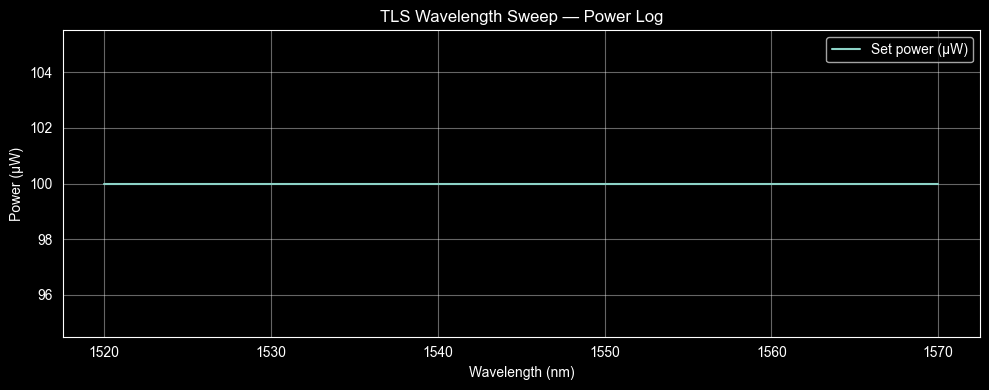

,wavelength_nm,set_power_w,set_power_uw,set_power_dbm,measured_power_w,measured_power_uw,measured_power_dbm
0,1520.0,0.0001,100.0,-10.0,NaN,NaN,NaN
1,1521.0,0.0001,100.0,-10.0,NaN,NaN,NaN
2,1522.0,0.0001,100.0,-10.0,NaN,NaN,NaN
3,1523.0,0.0001,100.0,-10.0,NaN,NaN,NaN
4,1524.0,0.0001,100.0,-10.0,NaN,NaN,NaN


In [74]:
# ── Example 7: Swept power log  ⚠️ enables the laser ─────────────────────────
df_sweep = tls_sweep_power_log(power_meter_query_fn=None)
display(df_sweep.head())

In [73]:
# ── Example 8: Check the error queue at any time ─────────────────────────────
tls_check_error()

  ERR: +0,"No error"


['+0,"No error"']

---
## 🔌 Cleanup

In [ ]:
tls_output_off()
tls.write('*GTL')
tls.close()
rm.close()
print("HP 8168 connection closed.")